In [43]:
import pandas as pd
import os

# Load the data
file_path = "/home/mjehangir/data_analysis/glioma_project_data_analysis/glioma_project/SV_analysis/sniffles_merged_all_samples_SVs_v8.txt"
df = pd.read_csv(file_path, sep="\t")

# Display the header (first few rows)
print(df.head())


    chr   start     end  size type filename arm
0  chr1   54754   54755     1  INS     3988   p
1  chr1   66252   66253     1  INS     3988   p
2  chr1   67911   68342   431  DEL     3988   p
3  chr1   83975   83976     1  INS     3988   p
4  chr1  136935  136936     1  INS     3988   p


Skipping BND (no defined color).


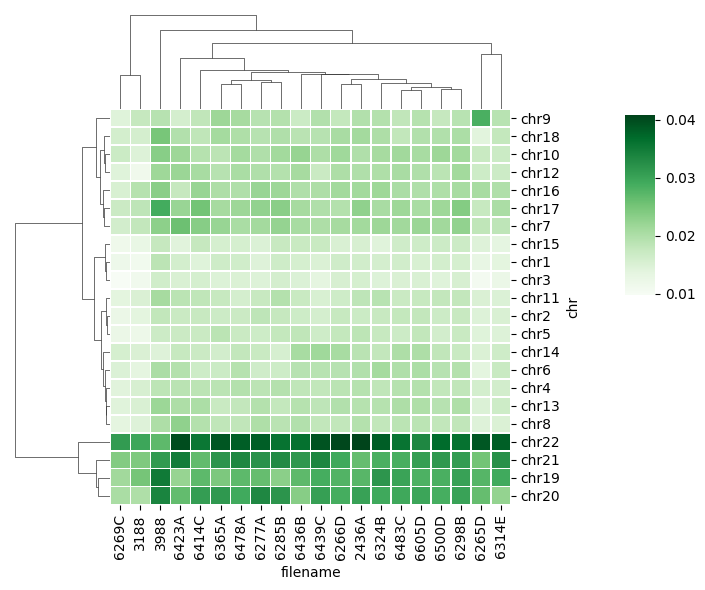

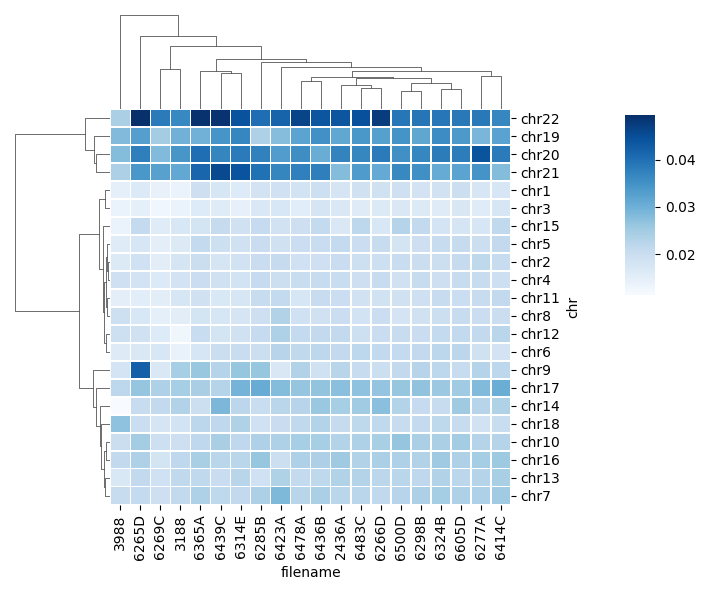

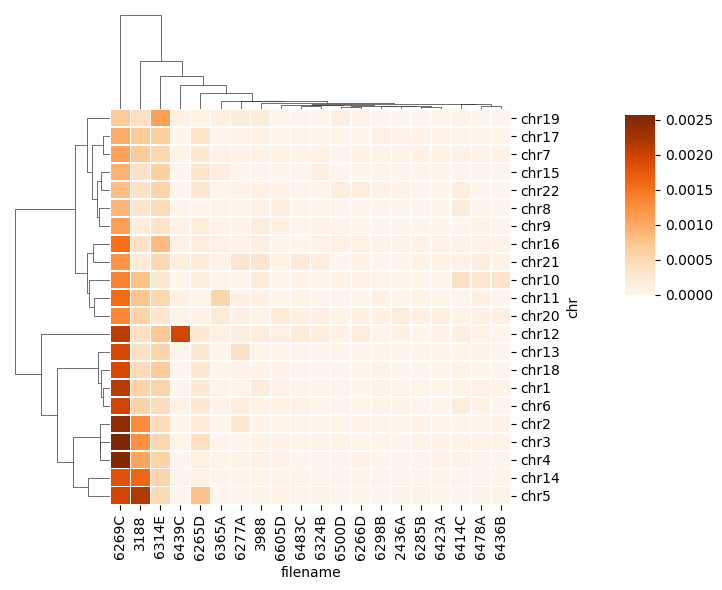

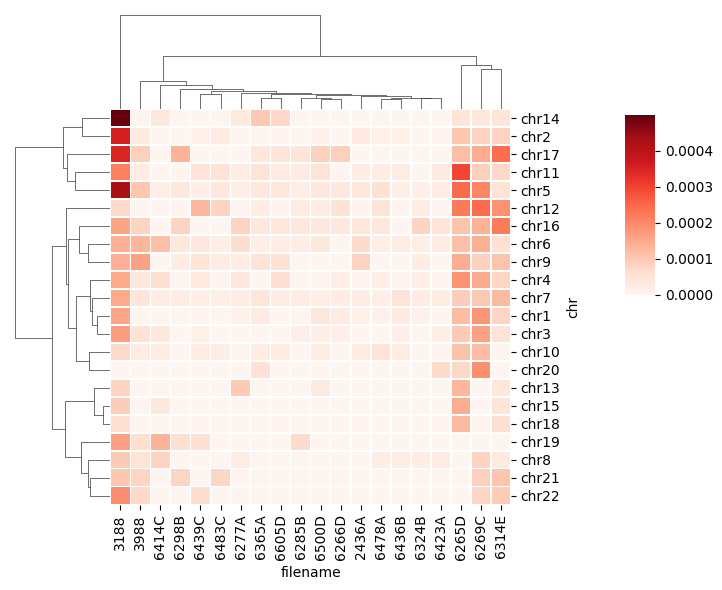

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# Define chromosome lengths (T2T genome)
chromosome_lengths = {
    "chr1": 248956422, "chr2": 242193529, "chr3": 198295559, "chr4": 190214555,
    "chr5": 181538259, "chr6": 170805979, "chr7": 159345973, "chr8": 145138636,
    "chr9": 138394717, "chr10": 133797422, "chr11": 135086622, "chr12": 133275309,
    "chr13": 114364328, "chr14": 107043718, "chr15": 101991189, "chr16": 90338345,
    "chr17": 83257441, "chr18": 80373285, "chr19": 58617616, "chr20": 64444167,
    "chr21": 46709983, "chr22": 50818468, "chrX": 156040895, "chrY": 57227415
}

# Load data
file_path = "/home/mjehangir/data_analysis/glioma_project_data_analysis/glioma_project/SV_analysis/sniffles_merged_all_samples_SVs_v7.txt"
df = pd.read_csv(file_path, sep="\t")

# Ensure proper column names (strip any accidental whitespace)
df.columns = df.columns.str.strip()

# Filter to include only valid chromosomes (based on T2T genome)
valid_chromosomes = list(chromosome_lengths.keys())
df = df[df['chr'].isin(valid_chromosomes)]

# Convert start and end positions to numeric values
df['start'] = pd.to_numeric(df['start'], errors='coerce')
df['end'] = pd.to_numeric(df['end'], errors='coerce')

# Define single-color colormaps for specific SV types
sv_colormaps = {
    "DEL": "Blues",
    "DUP": "Reds",
    "INV": "Oranges",
    "INS": "Greens"
}

# Get unique SV types from the 'type' column
sv_types = df['type'].unique()

# Calculate total SV counts per sample across all SV types for sorting
sv_counts_all = df.groupby(['filename', 'chr']).size().reset_index(name='SV_count')
sv_counts_all_pivoted = sv_counts_all.pivot_table(index='chr', columns='filename', values='SV_count', fill_value=0)

# Normalize counts by chromosome length (SVs per Mb)
for chrom in sv_counts_all_pivoted.index:
    chr_size_mb = chromosome_lengths.get(chrom, 1) / 1e6
    sv_counts_all_pivoted.loc[chrom] /= chr_size_mb

# Calculate total SVs per sample (sum across chromosomes)
total_sv_per_sample = sv_counts_all_pivoted.sum(axis=0)

# Sort the samples by total SV count (descending order)
sorted_columns = total_sv_per_sample.sort_values(ascending=False).index

# Process each SV type separately
for sv_type in sv_types:
    # Only proceed if the SV type has a defined colormap
    if sv_type not in sv_colormaps:
        print(f"Skipping {sv_type} (no defined color).")
        continue

    # Filter dataframe for the current SV type
    df_sv = df[df['type'] == sv_type]

    # Count SV occurrences per chromosome per sample
    sv_counts = df_sv.groupby(['chr', 'filename']).size().reset_index(name='SV_count')

    # Pivot the data to create a matrix with chromosomes as rows and samples as columns
    sv_matrix = sv_counts.pivot_table(index='chr', columns='filename', values='SV_count', fill_value=0)

    # Normalize counts by chromosome length (SVs per Mb)
    for chrom in sv_matrix.index:
        chr_size_mb = chromosome_lengths.get(chrom, 1) / 1e6
        sv_matrix.loc[chrom] /= chr_size_mb

    # Normalize by the total SV count per sample (SVs per sample)
    sv_matrix = sv_matrix.div(total_sv_per_sample, axis=1)

    # Reorder columns (samples) to match the sorted order based on total SV counts
    sv_matrix = sv_matrix[sorted_columns]

    # Skip plotting if the matrix is empty
    if sv_matrix.empty:
        print(f"Skipping {sv_type} because no data available.")
        continue

    # Compute a linkage matrix for clustering rows (chromosomes) - no clustering for columns (samples)
    row_linkage = sch.linkage(sv_matrix, method='ward')  # Hierarchical clustering for chromosomes

    # Create a clustermap: cluster only rows (chromosomes) but keep the columns (samples) sorted by total SV count
    g = sns.clustermap(
        sv_matrix,
        cmap=sv_colormaps[sv_type],
        row_cluster=True,  # Clustering chromosomes
        col_cluster=True,  # Do not cluster samples
        row_linkage=row_linkage,
        linewidths=0.5,
        figsize=(6, 6),
        annot=False,        # Set to True if you want to display the normalized values
        fmt='.2f',
        cbar_pos=(1.05, 0.5, 0.05, 0.3)  # Move legend to the right
    )


# Show the plot
plt.show()

Skipping BND (no defined color).
Saved DUP clustermap to /home/mjehangir/glioma_manuscript/fig1/sv_clustermaps_pdf/DUP_clustermap.pdf


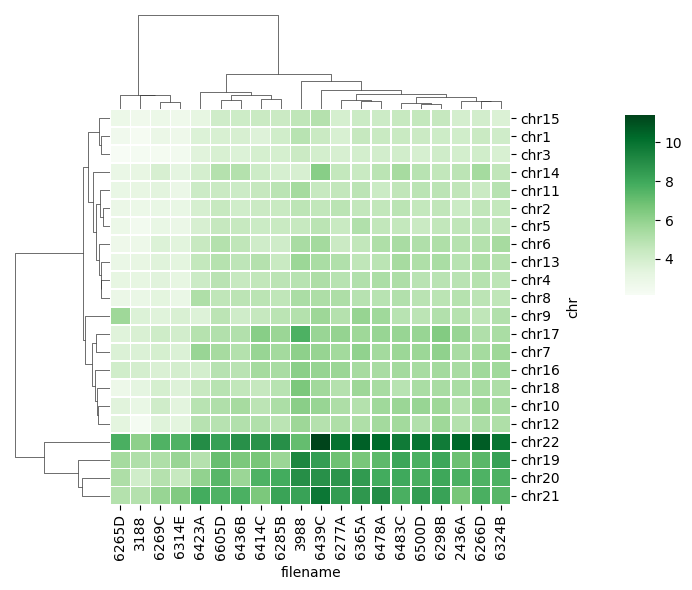

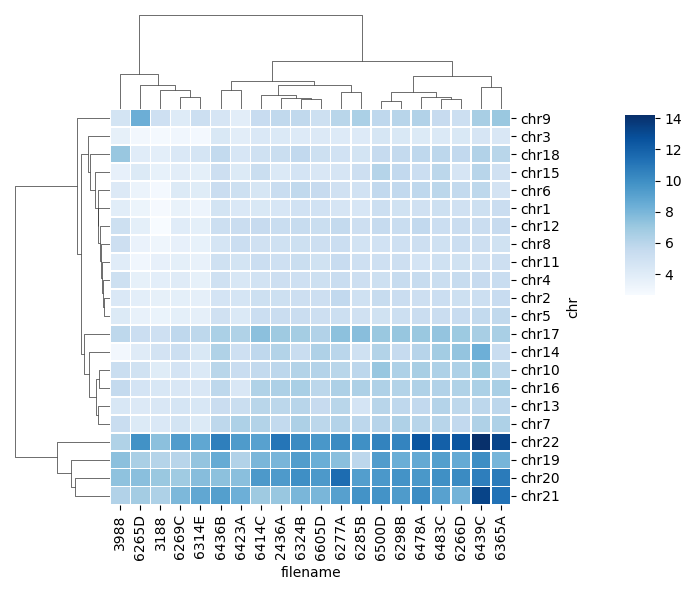

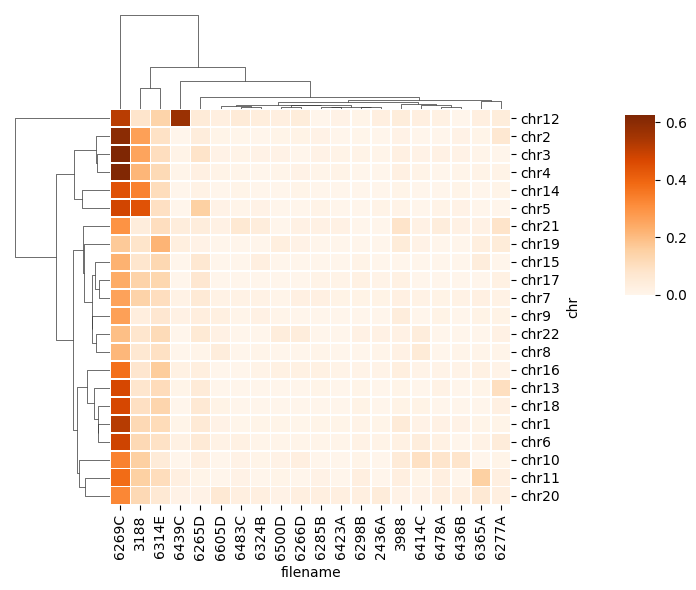

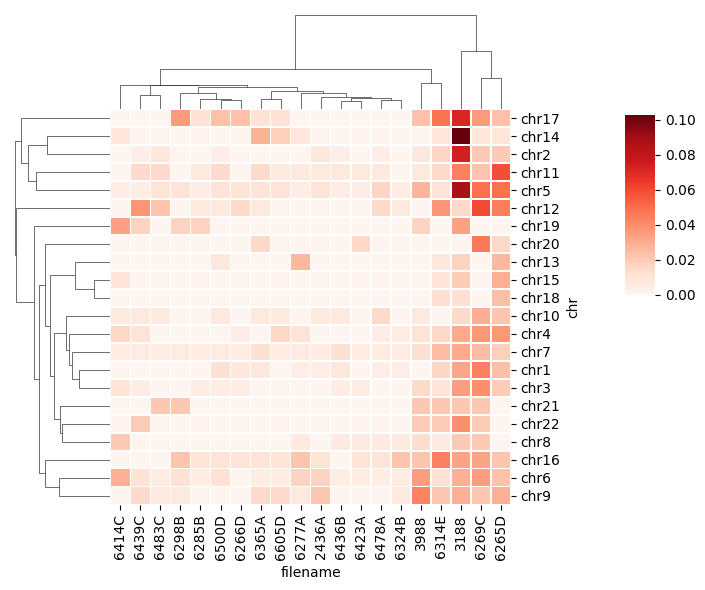

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# Define chromosome lengths (T2T genome, in base pairs)
chromosome_lengths = {
    "chr1": 248956422, "chr2": 242193529, "chr3": 198295559, "chr4": 190214555,
    "chr5": 181538259, "chr6": 170805979, "chr7": 159345973, "chr8": 145138636,
    "chr9": 138394717, "chr10": 133797422, "chr11": 135086622, "chr12": 133275309,
    "chr13": 114364328, "chr14": 107043718, "chr15": 101991189, "chr16": 90338345,
    "chr17": 83257441, "chr18": 80373285, "chr19": 58617616, "chr20": 64444167,
    "chr21": 46709983, "chr22": 50818468, "chrX": 156040895, "chrY": 57227415
}

# Load data
file_path = "/home/mjehangir/data_analysis/glioma_project_data_analysis/glioma_project/SV_analysis/sniffles_merged_all_samples_SVs_v7.txt"
df = pd.read_csv(file_path, sep="\t")

# Ensure proper column names (strip any accidental whitespace)
df.columns = df.columns.str.strip()

# Filter to include only valid chromosomes (based on T2T genome)
valid_chromosomes = list(chromosome_lengths.keys())
df = df[df['chr'].isin(valid_chromosomes)]

# Convert start and end positions to numeric values
df['start'] = pd.to_numeric(df['start'], errors='coerce')
df['end'] = pd.to_numeric(df['end'], errors='coerce')

# Define single-color colormaps for specific SV types
sv_colormaps = {
    "DEL": "Blues",
    "DUP": "Reds",
    "INV": "Oranges",
    "INS": "Greens"
}

# Get unique SV types from the 'type' column
sv_types = df['type'].unique()

# Calculate total SV counts per sample across all SV types for sorting
sv_counts_all = df.groupby(['filename', 'chr']).size().reset_index(name='SV_count')
sv_counts_all_pivoted = sv_counts_all.pivot_table(index='chr', columns='filename', values='SV_count', fill_value=0)

# Normalize counts by chromosome size (SVs per Mb)
for chrom in sv_counts_all_pivoted.index:
    chr_size_mb = chromosome_lengths.get(chrom, 1) / 1e6
    sv_counts_all_pivoted.loc[chrom] /= chr_size_mb

# Calculate total SVs per sample (sum across chromosomes)
total_sv_per_sample = sv_counts_all_pivoted.sum(axis=0)

# Sort the samples by total SV count (descending order)
sorted_columns = total_sv_per_sample.sort_values(ascending=False).index

# Process each SV type separately
for sv_type in sv_types:
    # Only proceed if the SV type has a defined colormap
    if sv_type not in sv_colormaps:
        print(f"Skipping {sv_type} (no defined color).")
        continue

    # Filter dataframe for the current SV type
    df_sv = df[df['type'] == sv_type]

    # Count SV occurrences per chromosome per sample
    sv_counts = df_sv.groupby(['chr', 'filename']).size().reset_index(name='SV_count')

    # Pivot the data to create a matrix with chromosomes as rows and samples as columns
    sv_matrix = sv_counts.pivot_table(index='chr', columns='filename', values='SV_count', fill_value=0)

    # Normalize counts by chromosome size (in Mb)
    for chrom in sv_matrix.index:
        chr_size_mb = chromosome_lengths.get(chrom, 1) / 1e6
        sv_matrix.loc[chrom] /= chr_size_mb

    # Reorder columns (samples) to match the sorted order based on total SV counts
    sv_matrix = sv_matrix[sorted_columns]

    # Skip plotting if the matrix is empty
    if sv_matrix.empty:
        print(f"Skipping {sv_type} because no data available.")
        continue

    # Compute a linkage matrix for clustering columns (samples)
    col_linkage = sch.linkage(sv_matrix.T, method='ward')  # Hierarchical clustering for samples


# Create a clustermap: cluster only columns (samples), keep the chromosome order fixed
    g = sns.clustermap(
        sv_matrix,
        cmap=sv_colormaps[sv_type],
        row_cluster=True,   # Do not cluster chromosomes
        col_cluster=True,    # Cluster samples
        col_linkage=col_linkage,
        linewidths=0.5,
        figsize=(6, 6),
        annot=False,         # Set to True if you want to display the normalized values
        fmt='.2f',
        cbar_pos=(1.05, 0.5, 0.05, 0.3)  # Adjust colorbar position
    ) 

    # Save each clustermap as PDF
    #out_pdf = os.path.join(output_dir, f"{sv_type}_clustermap.pdf")
    #g.fig.savefig(out_pdf, format='pdf', bbox_inches='tight')
    #print(f"Saved {sv_type} clustermap to {out_pdf}")

    #out_pdf = os.path.join(output_dir, f"{sv_type}_clustermap.svg")
    #g.fig.savefig(out_pdf, format='svg', bbox_inches='tight')
    #print(f"Saved {sv_type} clustermap to {out_pdf}")


import os
import matplotlib.pyplot as plt

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

out_pdf = os.path.join(output_dir, f"{sv_type}_clustermap.pdf")
g.fig.savefig(out_pdf, format='pdf', bbox_inches='tight')
print(f"Saved {sv_type} clustermap to {out_pdf}")

# Show all the plots
plt.show()



In [49]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# ── Configuration: ensure editable text in PDF ────────────────────────────
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

# ── Paths ────────────────────────────────────────────────────────────────────
# Adjust these paths to your environment
output_dir = "/home/mjehangir/glioma_manuscript/fig1/sv_clustermaps_pdf"  # directory where PDFs will be saved
file_path = (
    "/home/mjehangir/data_analysis/glioma_project_data_analysis/"
    "glioma_project/SV_analysis/sniffles_merged_all_samples_SVs_v7.txt"
)

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# ── Chromosome lengths for T2T genome (in base pairs) ─────────────────────
chromosome_lengths = {
    "chr1": 248956422, "chr2": 242193529, "chr3": 198295559, "chr4": 190214555,
    "chr5": 181538259, "chr6": 170805979, "chr7": 159345973, "chr8": 145138636,
    "chr9": 138394717, "chr10": 133797422, "chr11": 135086622, "chr12": 133275309,
    "chr13": 114364328, "chr14": 107043718, "chr15": 101991189, "chr16": 90338345,
    "chr17": 83257441, "chr18": 80373285, "chr19": 58617616, "chr20": 64444167,
    "chr21": 46709983, "chr22": 50818468, "chrX": 156040895, "chrY": 57227415
}

# ── Load and preprocess data ─────────────────────────────────────────────────
df = pd.read_csv(file_path, sep="\t")
df.columns = df.columns.str.strip()  # strip whitespace from column names

# Filter to valid chromosomes
valid_chromosomes = list(chromosome_lengths.keys())
df = df[df['chr'].isin(valid_chromosomes)]

# Convert start/end to numeric
df['start'] = pd.to_numeric(df['start'], errors='coerce')
df['end'] = pd.to_numeric(df['end'], errors='coerce')

# ── SV colormaps ────────────────────────────────────────────────────────────
sv_colormaps = {
    "DEL": "Blues",
    "DUP": "Reds",
    "INV": "Oranges",
    "INS": "Greens"
}

# Identify SV types
sv_types = df['type'].unique()

# Calculate total SVs per sample (all types) for ordering
sv_counts_all = df.groupby(['filename', 'chr']).size().reset_index(name='SV_count')
sv_counts_pivot = sv_counts_all.pivot_table(
    index='chr', columns='filename', values='SV_count', fill_value=0
)
# Normalize by chromosome length (Mb)
for chrom in sv_counts_pivot.index:
    sv_counts_pivot.loc[chrom] /= (chromosome_lengths[chrom] / 1e6)
# Total per sample
total_sv_per_sample = sv_counts_pivot.sum(axis=0)
# Sort samples descending
sorted_samples = total_sv_per_sample.sort_values(ascending=False).index

# ── Plot and save clustermaps ───────────────────────────────────────────────
for sv_type in sv_types:
    if sv_type not in sv_colormaps:
        print(f"Skipping {sv_type} (no colormap defined)")
        continue

    # Filter for this SV type
    df_sv = df[df['type'] == sv_type]
    if df_sv.empty:
        print(f"No data for {sv_type}, skipping.")
        continue

    # Count per chr/sample
    counts = df_sv.groupby(['chr', 'filename']).size().reset_index(name='SV_count')
    matrix = counts.pivot_table(
        index='chr', columns='filename', values='SV_count', fill_value=0
    )
    # Normalize by chr length
    for chrom in matrix.index:
        matrix.loc[chrom] /= (chromosome_lengths[chrom] / 1e6)
    # Reorder samples
    matrix = matrix[sorted_samples.intersection(matrix.columns)]

    # Cluster samples
    col_linkage = sch.linkage(matrix.T, method='ward')

    # Draw clustermap
    g = sns.clustermap(
        matrix,
        cmap=sv_colormaps[sv_type],
        row_cluster=True,
        col_cluster=True,
        col_linkage=col_linkage,
        linewidths=0.5,
        figsize=(6, 6),
        annot=False,
        fmt='.2f',
        cbar_pos=(1.05, 0.5, 0.05, 0.3)
    )

    # Save inside loop
    out_pdf = os.path.join(output_dir, f"{sv_type}_clustermap.pdf")
    g.fig.savefig(out_pdf, format='pdf', bbox_inches='tight')
    print(f"Saved {sv_type} clustermap to {out_pdf}")

    # Close figure for next iteration
    plt.close(g.fig)


Saved INS clustermap to /home/mjehangir/glioma_manuscript/fig1/sv_clustermaps_pdf/INS_clustermap.pdf
Saved DEL clustermap to /home/mjehangir/glioma_manuscript/fig1/sv_clustermaps_pdf/DEL_clustermap.pdf
Skipping BND (no colormap defined)
Saved INV clustermap to /home/mjehangir/glioma_manuscript/fig1/sv_clustermaps_pdf/INV_clustermap.pdf
Saved DUP clustermap to /home/mjehangir/glioma_manuscript/fig1/sv_clustermaps_pdf/DUP_clustermap.pdf
